# 02 — Explorando os Dados

Antes de modelar eu quis entender como o peso se comporta nos meus dados. 
A pergunta que me guiou aqui foi: **o que faz o camarão crescer?** E, principalmente, será que o tempo
de cultivo tem uma relação tão forte com o peso quanto eu li nos artigos?

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=100; plt.rcParams['axes.grid']=True; plt.rcParams['grid.alpha']=0.3

In [2]:
from src.features import aplicar_filtros_fisicos
diario = aplicar_filtros_fisicos(pd.read_csv("../data/processed/dataset_completo.csv", low_memory=False))
bio = diario[(diario["FASE"]=="engorda") & (diario["EH_BIOMETRIA"]==1)].copy() if "FASE" in diario.columns else diario[diario["EH_BIOMETRIA"]==1].copy()
print(f"{len(bio)} biometrias (pesagens reais)")

2199 biometrias (pesagens reais)


## A distribuição do peso

O peso vai de pós-larvas de menos de 1g até camarões de ~38g na despesca. É essa faixa
que meu modelo vai tentar prever.

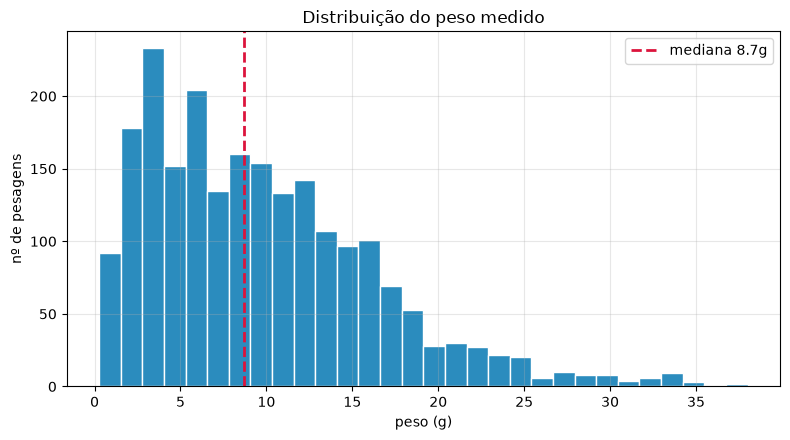

In [3]:
plt.figure(figsize=(8,4.5))
plt.hist(bio["PESO"].dropna(), bins=30, color="#2b8cbe", edgecolor="white")
plt.axvline(bio["PESO"].median(), color="crimson", ls="--", lw=2, label=f"mediana {bio['PESO'].median():.1f}g")
plt.xlabel("peso (g)"); plt.ylabel("nº de pesagens"); plt.title("Distribuição do peso medido"); plt.legend()
plt.tight_layout(); plt.show()

## A descoberta que definiu meu trabalho: peso × dias de cultivo

Aqui está o gráfico mais importante da minha exploração. Quando eu plotei o peso contra
os dias de cultivo, a relação é quase uma linha crescente: camarão de 30 dias é pequeno,
de 100 dias é grande, de forma muito previsível. 
Foi isso que me fez decidir usar os dias de cultivo como preditor principal — a mesma escolha do estudo da Indonésia (Mujahid et
al., 2025), que também usou o "day of culture" como variável central.

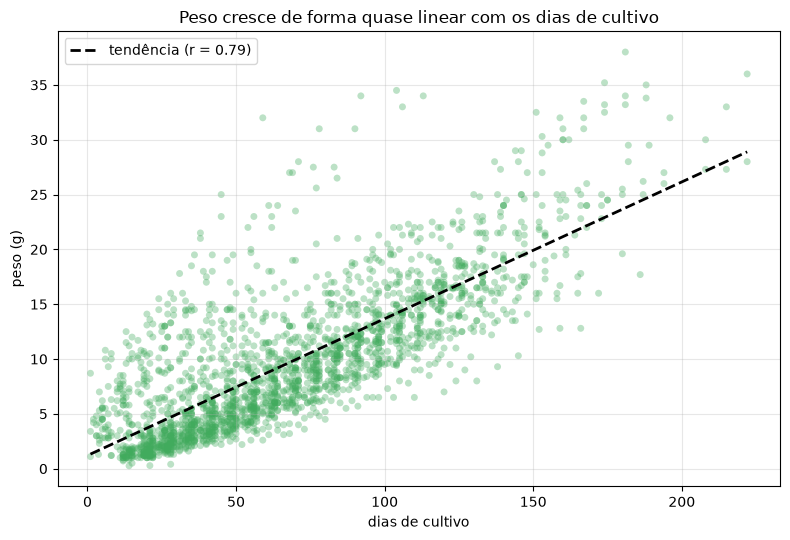

In [4]:
d = bio.dropna(subset=["DIAS","PESO"])
plt.figure(figsize=(8,5.5))
plt.scatter(d["DIAS"], d["PESO"], alpha=0.35, color="#41ab5d", edgecolor="none", s=25)
z = np.polyfit(d["DIAS"], d["PESO"], 1)
xs = np.linspace(d["DIAS"].min(), d["DIAS"].max(), 50)
plt.plot(xs, np.polyval(z, xs), "k--", lw=2, label=f"tendência (r = {d['DIAS'].corr(d['PESO']):.2f})")
plt.xlabel("dias de cultivo"); plt.ylabel("peso (g)")
plt.title("Peso cresce de forma quase linear com os dias de cultivo")
plt.legend(); plt.tight_layout(); plt.show()

A correlação alta confirma o que eu tinha lido: o tempo de cultivo é o motor do
crescimento. Essa foi a base da minha ideia de modelagem, se o peso depende tão
fortemente do tempo, um modelo que recebe os dias de cultivo (junto com ração e ambiente)
deveria prever o peso muito bem.

**Próximo (03):** como preparei as variáveis pro modelo.